### Importing Libraries and loading dataset

##### Dataset taken from Kaggle: https://www.kaggle.com/code/jijagallery/retail-store-inventory-forecasting/input 
This dataset is used to predict sales quantity with regression models and provide insights to optimize inventory levels, enhance demand prediction and minimize overstocking.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.express as px
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn import metrics # imports entire metrics module from scikit-learn library
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error # imports r2 score, MSE and MAE from sklearn import metrics

In [2]:
# Create a connection to SQLite database using Python's sqlite3 library
# SQLite is a lightweight, file-based database — unlike big databases like MySQL or PostgreSQL that run on a server, 
# SQLite just lives as a single file on your computer
con = sqlite3.connect('test_db.db')

In [3]:
# Reading csv into df
df = pd.read_csv('retail_store_inventory.csv')
print(df.shape)
df.head()

(73100, 15)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,1/1/2022,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,1/1/2022,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,1/1/2022,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,1/1/2022,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,1/1/2022,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [4]:
# Storing/saving the CSV data/df in the test_db db (database)
# This took your df (the data you loaded from CSV) and saved it as a table called 'rsi' inside the SQLite database.
df.to_sql(name='rsi',con=con, index=False, if_exists='replace')

73100

In [5]:
# Select the columns from Table
## Execute SQL query and load results into a Dataframe
# This used SQL syntax to pull the data back out of the database into a pandas DataFrame.
sql_query = '''
SELECT * 
FROM rsi
'''
pd.read_sql(sql_query,con)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,1/1/2022,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,1/1/2022,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,1/1/2022,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,1/1/2022,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,1/1/2022,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73095,1/1/2024,S005,P0016,Furniture,East,96,8,127,18.46,73.73,20,Snowy,0,72.45,Winter
73096,1/1/2024,S005,P0017,Toys,North,313,51,101,48.43,82.57,10,Cloudy,0,83.78,Autumn
73097,1/1/2024,S005,P0018,Clothing,West,278,36,151,39.65,11.11,10,Rainy,0,10.91,Winter
73098,1/1/2024,S005,P0019,Toys,East,374,264,21,270.52,53.14,20,Rainy,0,55.80,Spring


### Exploratory Data Analysis

In [6]:
# Display the column names
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='object')

In [7]:
# Provides key information about a dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [8]:
# Provides statistical summary of the numerical columns in a DataFrame 
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [9]:
# Check for any null values
print("Missing Values:")
df.isnull().sum()

Missing Values:


Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

In [10]:
# display frequency count for categorical columns
column_freq_count=df.select_dtypes(include=['object']).columns # filters the dataframe to only the columns whose datatye is object 
for col in column_freq_count:                                  # loop then goes through each of those column names one at a time
    print (f"Frequency counts for {col}:")                     # for each column, prints a header showing which column the stats below belong to
    print (df[col].value_counts())                             # prints a count of how many times each unique value occurs in that column

Frequency counts for Date:
Date
1/1/2024     100
1/1/2022     100
2/1/2022     100
3/1/2022     100
4/1/2022     100
            ... 
16/1/2022    100
15/1/2022    100
14/1/2022    100
13/1/2022    100
12/1/2022    100
Name: count, Length: 731, dtype: int64
Frequency counts for Store ID:
Store ID
S001    14620
S002    14620
S003    14620
S004    14620
S005    14620
Name: count, dtype: int64
Frequency counts for Product ID:
Product ID
P0001    3655
P0002    3655
P0003    3655
P0004    3655
P0005    3655
P0006    3655
P0007    3655
P0008    3655
P0009    3655
P0010    3655
P0011    3655
P0012    3655
P0013    3655
P0014    3655
P0015    3655
P0016    3655
P0017    3655
P0018    3655
P0019    3655
P0020    3655
Name: count, dtype: int64
Frequency counts for Category:
Category
Furniture      14699
Toys           14643
Clothing       14626
Groceries      14611
Electronics    14521
Name: count, dtype: int64
Frequency counts for Region:
Region
East     18349
South    18297
North    18228
West

In [11]:
print(df['Date'].dtype)

object


In [12]:
# Attempt to convert the 'Date' column to datetime, specifying the format
# dayfirst=True means day comes first (e.g., DD/MM/YYYY)
# errors=coerce means any invalid parsing will be set as Not a Time (NaT)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce') 

# Check for missing dates after conversion
print("Missing dates (NaT):", df['Date'].isnull().sum())

Missing dates (NaT): 0


In [13]:
# Check if the date type has been changed to datetime
print(df['Date'].dtype)

datetime64[ns]


In [14]:
print(df['Date'].describe())

count                            73100
mean     2022-12-31 23:59:59.999999744
min                2022-01-01 00:00:00
25%                2022-07-02 00:00:00
50%                2023-01-01 00:00:00
75%                2023-07-03 00:00:00
max                2024-01-01 00:00:00
Name: Date, dtype: object


In [15]:
print(f"Total number of products: {df['Product ID'].nunique()}")
print(f"Date range: from {df['Date'].min()} to {df['Date'].max()}")

Total number of products: 20
Date range: from 2022-01-01 00:00:00 to 2024-01-01 00:00:00


This is now confirmed that I have daily transaction from 1/1/2022 to 1/1/2024 without missing values/rows in the dataset

In [16]:
# Use the .rename() method to rename column name
# inplace=True means directly renaming the column instead of creating a new column in the dataset. 

df.rename(columns={'Inventory Level':'Stock_level'}, inplace=True)
df.rename(columns={'Units Sold':'Sales_qty'}, inplace=True)
df.rename(columns={'Units Ordered':'Order_qty'}, inplace=True)
df.rename(columns={'Store ID':'Store'}, inplace=True)
df.rename(columns={'Product ID':'Product'}, inplace=True)
df.rename(columns={'Weather Condition':'Weather'}, inplace=True)

In [17]:
# Quick check - see if Demand Forecast is suspiciously similar to Sales_qty
print(df[['Sales_qty', 'Demand Forecast']].corr())

                 Sales_qty  Demand Forecast
Sales_qty         1.000000         0.996853
Demand Forecast   0.996853         1.000000


This shows that the demand forecast have strong correlation (0.99) with sales qty  and it should be dropped off from df to avoid data leakage and including this feature may cause the model to perform unrealistically well.

In [18]:
# Drop Demand Forecast only - likely causes data leakage 
# (too closely related to Sales_qty, the value we're predicting)
df.drop(columns=['Demand Forecast'], inplace=True)

In [19]:
# check the first 5 rows of the dataframe after renaming and dropping columns

df.head()

,Date,Store,Product,Category,Region,Stock_level,Sales_qty,Order_qty,Price,Discount,Weather,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,73.64,0,Sunny,0,68.95,Summer


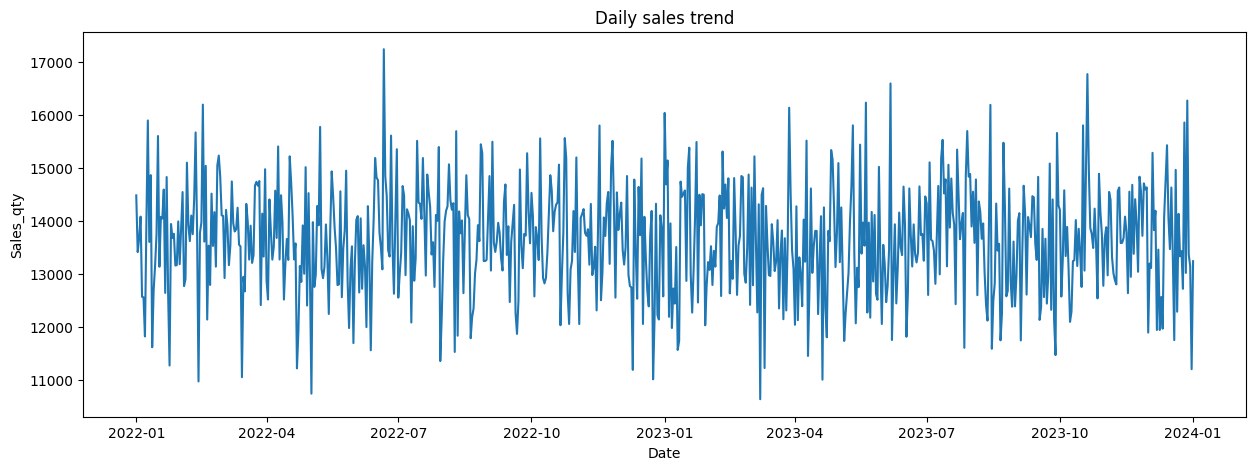

In [20]:
# Visualise the sum of daily sales and review if there is any trend

daily_sales = df.groupby('Date')['Sales_qty'].sum().reset_index()

# Plot daily sales with matplotlib
plt.figure(figsize=(15, 5))
plt.plot(daily_sales['Date'], daily_sales['Sales_qty'])
plt.title('Daily sales trend')
plt.xlabel('Date')
plt.ylabel('Sales_qty')
plt.show()

Overall, the graph show consistent flunctuation in daily sales without any obvious spikes or drastic declines.

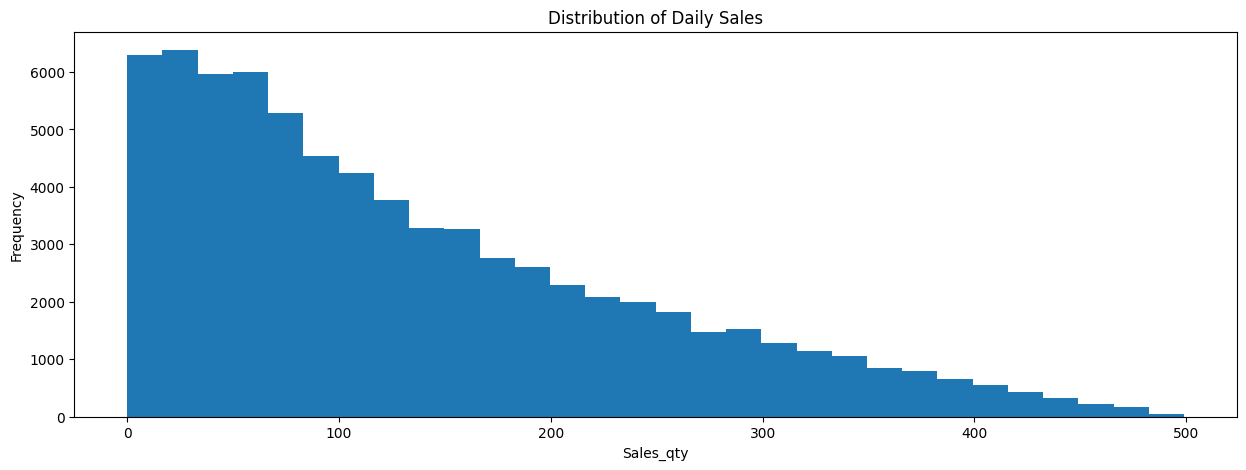

In [21]:
# Visualize the distribution of Sales

plt.figure(figsize=(15, 5))
plt.hist(df['Sales_qty'], bins=30) # bins=30 specifies the number of bins the data is distributed to
plt.title('Distribution of Daily Sales')
plt.xlabel('Sales_qty')
plt.ylabel('Frequency')
plt.show()

Based on the histogram above, the highest frequency/occurrences of product sales is between 0 to 100 quantity daily.

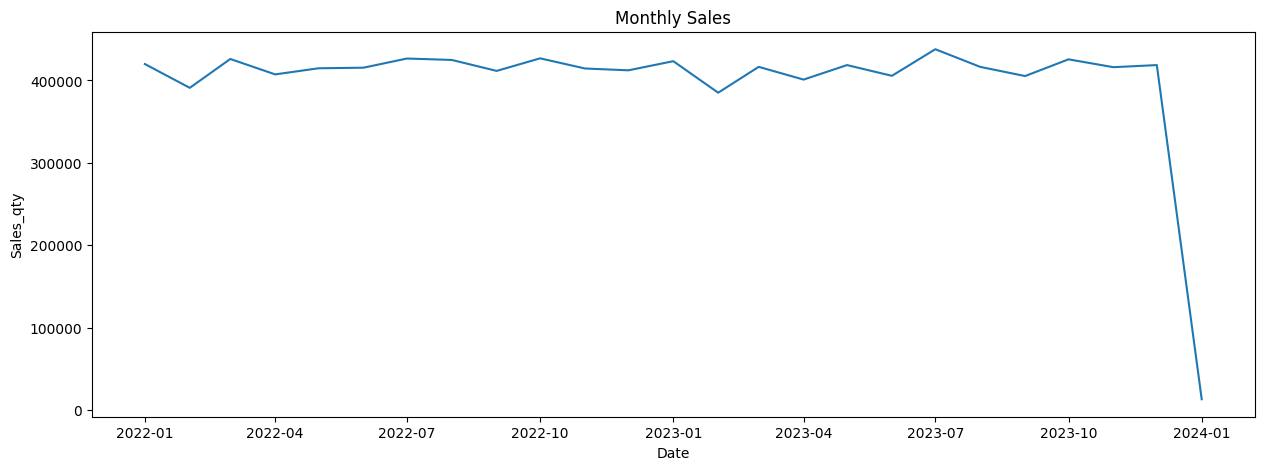

In [22]:
# Monthly Sales trend

monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Sales_qty'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Date'].dt.to_timestamp()
plt.figure(figsize=(15, 5))
plt.plot(monthly_sales['Date'], monthly_sales['Sales_qty']) 
plt.title('Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Sales_qty')
plt.show()

The monthly sales trend below reveals a stable sales trend between 300,000 and 400,000 units per month over the two-year period. However, sales suddenly dropped in January 2024 because during January that year, the sales record only has 1st January records while other years, the sales record is based on all the days in the month of January.

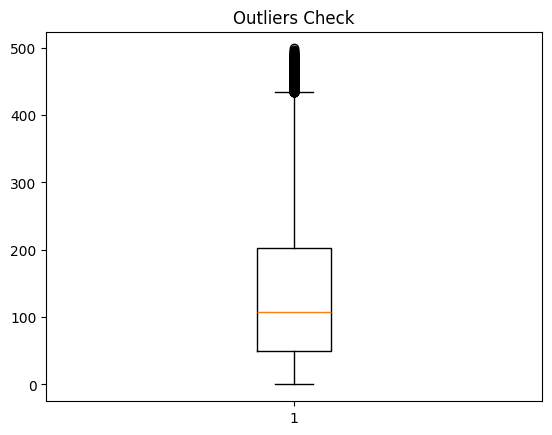

In [23]:
# Check for outliers

plt.boxplot(df['Sales_qty'])
plt.title('Outliers Check')
plt.show()

The box plot visualizes the distribution of sales quantity in the data set. It shows that 100 is the median sales quantity and interquartile range between 50 to 200. The outliers is above 400 which is rare or unusually high demand.

In [24]:
# Finding the product category with the highest sales

# Group by Category and sum up Sales_qty
category_sales = df.groupby('Category')['Sales_qty'].sum()

# Sort to see highest first
category_sales = category_sales.sort_values(ascending=False)

print(category_sales)

# Get just the top category name
top_category = category_sales.idxmax()
print(f"\nHighest selling category: {top_category}")

Category
Furniture      2025017
Groceries      2000482
Clothing       1999166
Toys           1990485
Electronics    1960432
Name: Sales_qty, dtype: int64

Highest selling category: Furniture


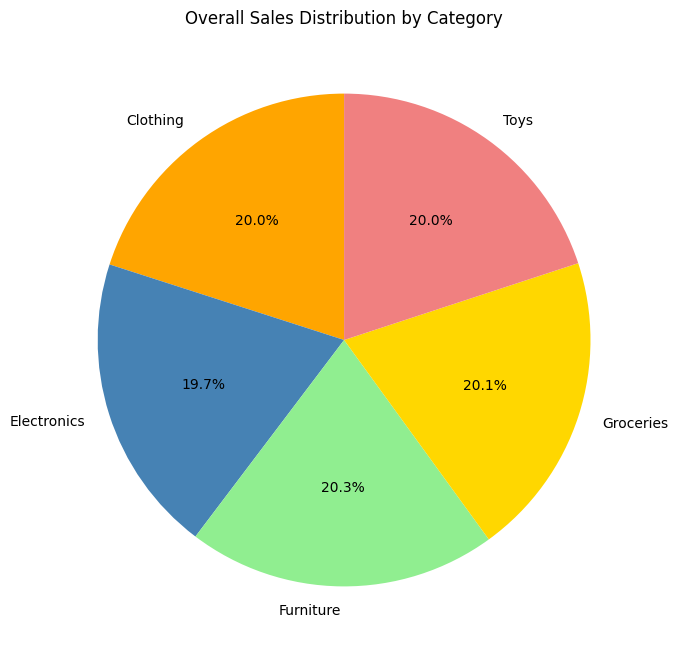

In [25]:
# Calculate total sales by category
category_sales = df.groupby('Category')['Sales_qty'].sum()

plt.figure(figsize=(8, 8))
plt.pie(category_sales, 
        labels=category_sales.index, 
        autopct='%1.1f%%',
        startangle=90,
        colors=['orange', 'steelblue', 'lightgreen', 'gold', 'lightcoral'])

plt.title('Overall Sales Distribution by Category')
plt.show()

This piechart shows the proportion of total sales contributed by each category. Furniture emerges as the top contributor.

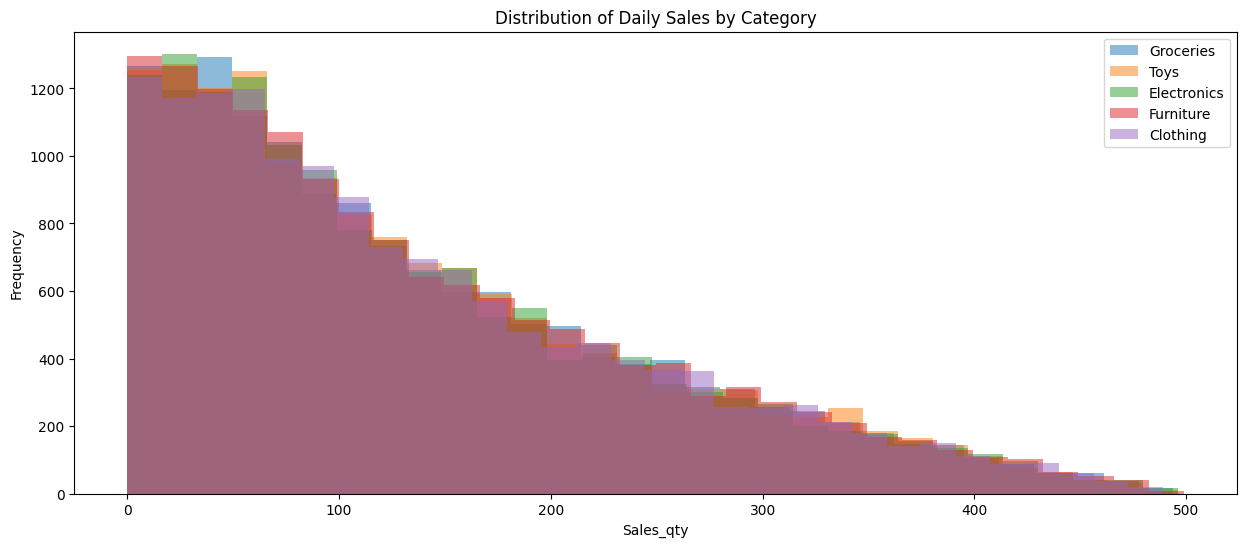

In [26]:
plt.figure(figsize=(15, 6))

# Plot each category's distribution separately
categories = df['Category'].unique()

for category in categories:
    category_data = df[df['Category'] == category]['Sales_qty']
    plt.hist(category_data, bins=30, alpha=0.5, label=category)

plt.title('Distribution of Daily Sales by Category')
plt.xlabel('Sales_qty')
plt.ylabel('Frequency')
plt.legend()
plt.show()

From this chart, all 5 categories follow a similar right-skewed shape. Mostly daily sales cluster between 0-100 units across categories. No single category stands out as dramatically different. 

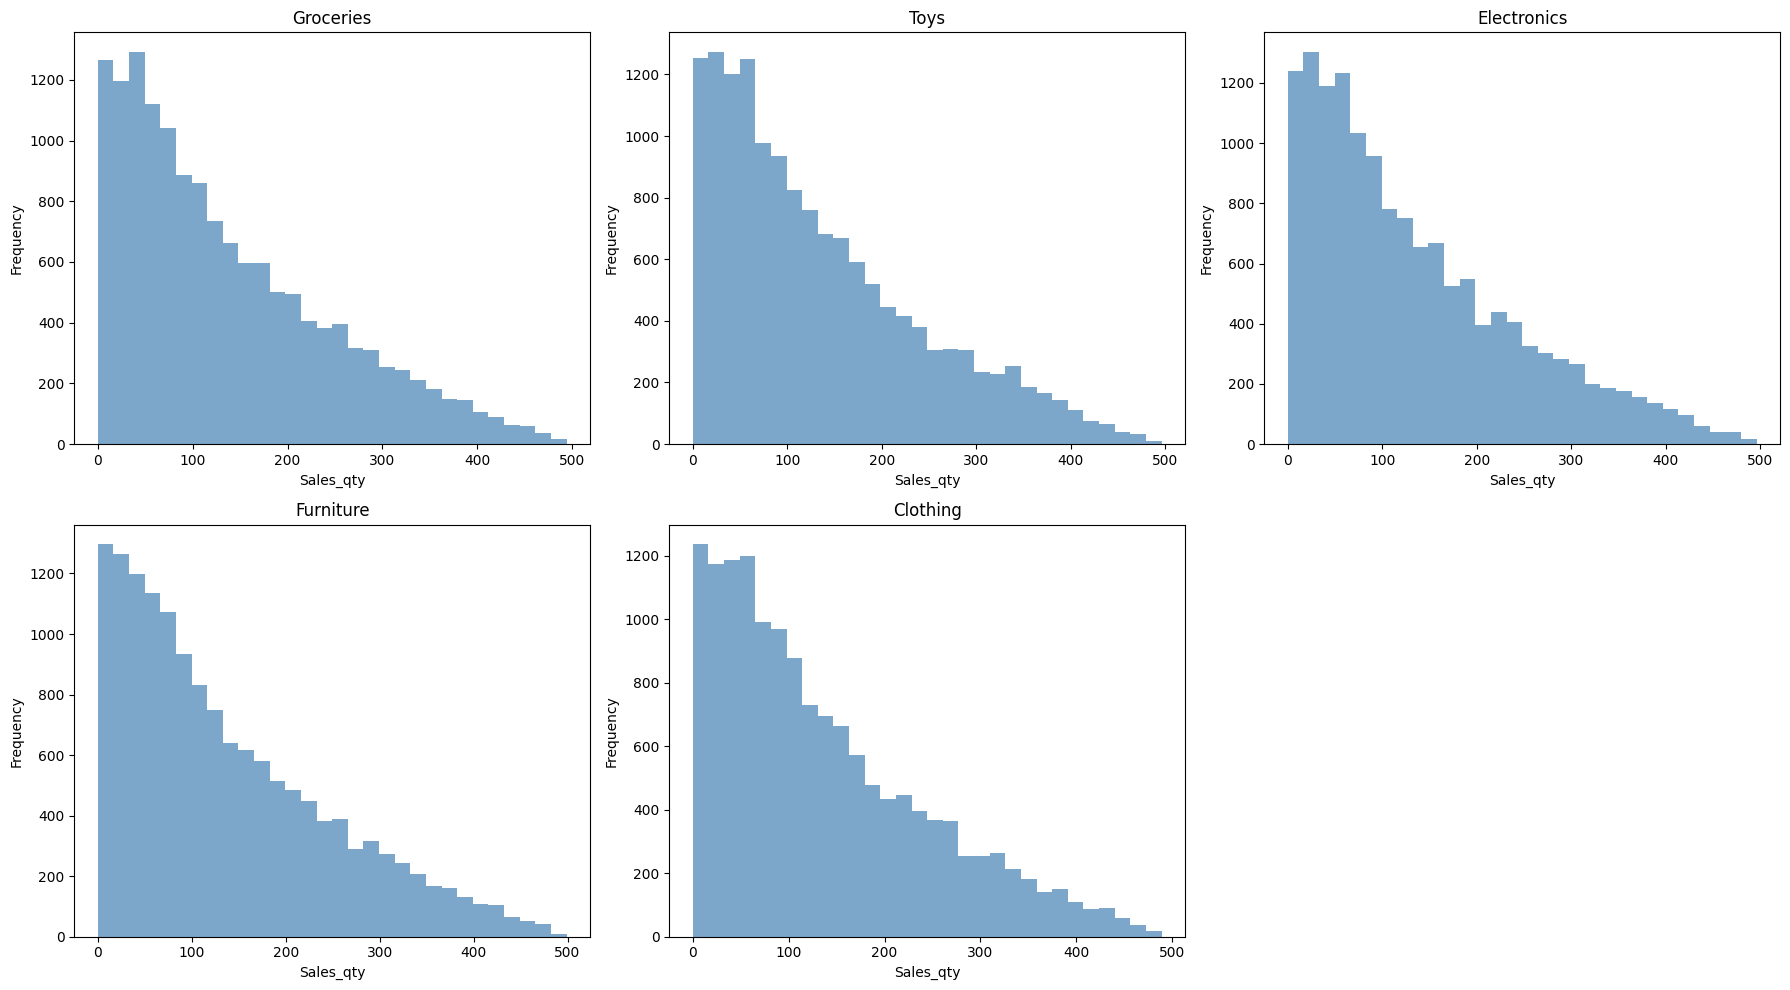

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

categories = df['Category'].unique()
for i, category in enumerate(categories):
    category_data = df[df['Category'] == category]['Sales_qty']
    axes[i].hist(category_data, bins=30, color='steelblue', alpha=0.7)
    axes[i].set_title(category)
    axes[i].set_xlabel('Sales_qty')
    axes[i].set_ylabel('Frequency')

# Hide the unused 6th subplot (since you only have 5 categories)
axes[5].axis('off')

plt.tight_layout()
plt.show()

This comparison examines whether each product category has a distinct sales distribution shape. All five categories show similar right-skewed distributions, with most daily sales falling between 0-100 units. This visual finding supports the earlier correlation analysis, which showed Category has minimal linear relationship with Sales Quantity - confirming that demand patterns are broadly consistent across product types.

In [28]:
# Top 10 Sales Category & Product

grouping_cols = ['Category','Product']
highest_sales = df.groupby(grouping_cols)['Sales_qty'].max()
top_sales = highest_sales.sort_values(ascending=False)
print(top_sales.head(10))

Category     Product
Furniture    P0018      499
Electronics  P0001      496
Toys         P0012      496
             P0017      495
Groceries    P0008      494
             P0013      494
             P0012      493
Electronics  P0016      492
Groceries    P0007      491
Electronics  P0017      491
Name: Sales_qty, dtype: int64


In [29]:
# Count the number of unique Products in each Category
product_counts = df.groupby('Category')['Product'].nunique().reset_index()

# Rename the columns for clarity
product_counts.columns = ['Category', 'Unique Product Count']

print(product_counts)                             

      Category  Unique Product Count
0     Clothing                    20
1  Electronics                    20
2    Furniture                    20
3    Groceries                    20
4         Toys                    20


In [30]:
# Check the unique Product appear in which category
# Create a boolean crosstab showing Product presence in each Category
# This function creates a cross-tabulation of two(or more) factors

presence_df = pd.crosstab(df['Product'], df['Category']).astype(bool) 
print(presence_df)

Category  Clothing  Electronics  Furniture  Groceries  Toys
Product                                                    
P0001         True         True       True       True  True
P0002         True         True       True       True  True
P0003         True         True       True       True  True
P0004         True         True       True       True  True
P0005         True         True       True       True  True
P0006         True         True       True       True  True
P0007         True         True       True       True  True
P0008         True         True       True       True  True
P0009         True         True       True       True  True
P0010         True         True       True       True  True
P0011         True         True       True       True  True
P0012         True         True       True       True  True
P0013         True         True       True       True  True
P0014         True         True       True       True  True
P0015         True         True       Tr

In [31]:
df.head()

,Date,Store,Product,Category,Region,Stock_level,Sales_qty,Order_qty,Price,Discount,Weather,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,73.64,0,Sunny,0,68.95,Summer


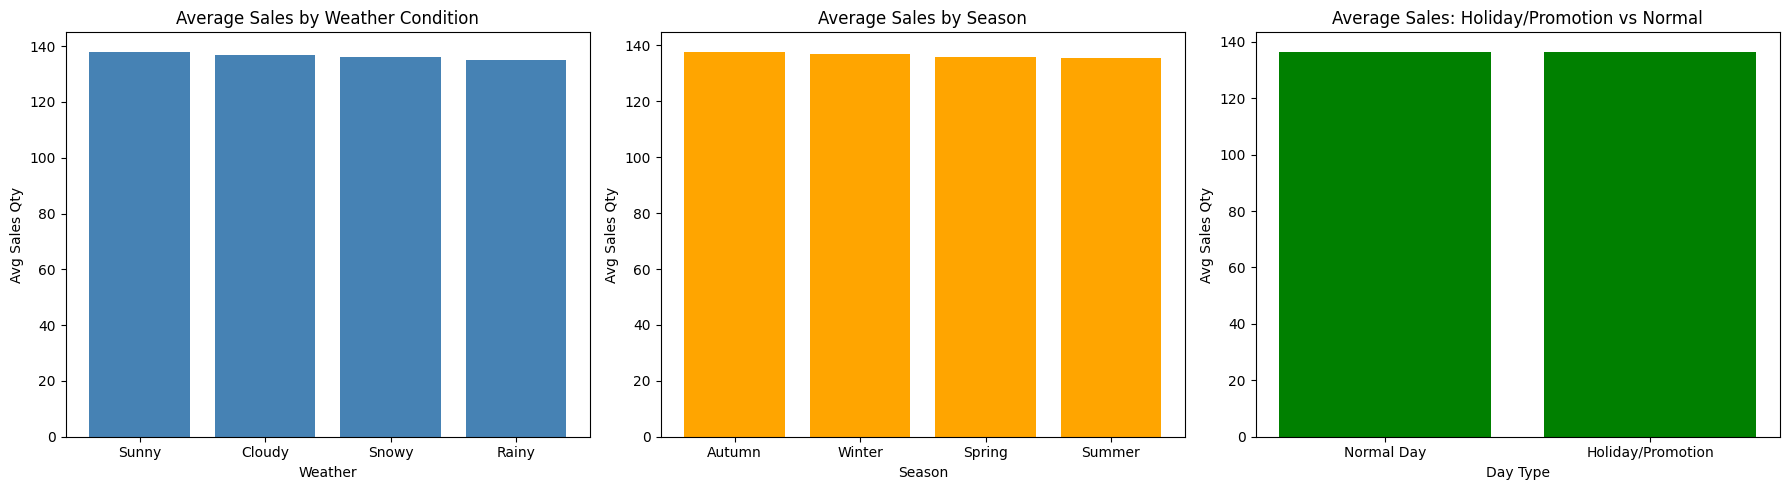

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Average sales by Weather
weather_avg = df.groupby('Weather')['Sales_qty'].mean().sort_values(ascending=False)
axes[0].bar(weather_avg.index, weather_avg.values, color='steelblue')
axes[0].set_title('Average Sales by Weather Condition')
axes[0].set_xlabel('Weather')
axes[0].set_ylabel('Avg Sales Qty')

# Average sales by Seasonality
season_avg = df.groupby('Seasonality')['Sales_qty'].mean().sort_values(ascending=False)
axes[1].bar(season_avg.index, season_avg.values, color='orange')
axes[1].set_title('Average Sales by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Avg Sales Qty')

# Average sales: Holiday/Promotion vs Normal
holiday_avg = df.groupby('Holiday/Promotion')['Sales_qty'].mean()
axes[2].bar(['Normal Day', 'Holiday/Promotion'], holiday_avg.values, color='green')
axes[2].set_title('Average Sales: Holiday/Promotion vs Normal')
axes[2].set_xlabel('Day Type')
axes[2].set_ylabel('Avg Sales Qty')

plt.tight_layout()
plt.show()

Average sales remain relatively flat across weather conditions, seasons and holiday /promotion days. This visually confirm there's no obvious linear pattern. 

In [33]:
print("Weather averages:")
print(weather_avg)
print("\nSeason averages:")
print(season_avg)
print("\nHoliday/Promotion averages:")
print(holiday_avg)

Weather averages:
Weather
Sunny     138.028650
Cloudy    136.758324
Snowy     135.911559
Rainy     135.160028
Name: Sales_qty, dtype: float64

Season averages:
Seasonality
Autumn    137.782444
Winter    136.830790
Spring    135.826828
Summer    135.428298
Name: Sales_qty, dtype: float64

Holiday/Promotion averages:
Holiday/Promotion
0    136.505375
1    136.423926
Name: Sales_qty, dtype: float64


The differences in average sales across Weather (135.2–138.0), Season (135.4–137.8), and Holiday/Promotion (136.4 vs 136.5) are minimal - all values cluster tightly within a narrow range of just 1–3 units. Holiday/Promotion in particular shows almost no difference (136.4 vs 136.5), suggesting it has virtually no effect on average sales quantity in this dataset.

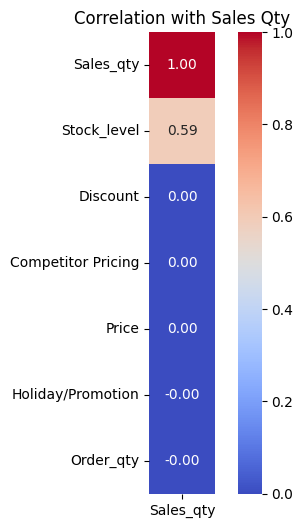

In [34]:
# Select all relevant numerical columns (Demand Forecast already dropped earlier)
numeric_df = df[['Stock_level', 'Sales_qty', 'Order_qty', 
                  'Price', 'Discount', 'Competitor Pricing', 
                  'Holiday/Promotion']]

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Filter and sort by correlation with Sales_qty
order_corr = corr_matrix[['Sales_qty']].sort_values(by='Sales_qty', ascending=False)

# Plot the heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(order_corr, annot=True, cmap='coolwarm', cbar=True, fmt='.2f', square=True)
plt.title("Correlation with Sales Qty")
plt.show()

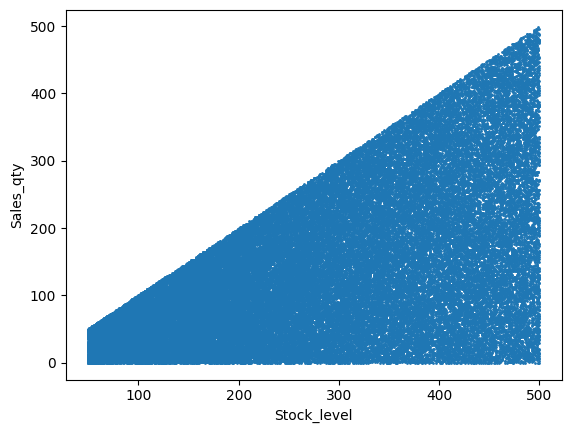

In [35]:
# Plot Sales Qty vs. Stock Level
plt.scatter(df["Stock_level"], df["Sales_qty"], s=1)
plt.xlabel('Stock_level')
plt.ylabel('Sales_qty')
plt.show()

This scatter plot shows how stock level correlates with sales quantity. Since the points form a triangular shape, it suggests that higher stock levels tend to be associated with higher sales quantities. This positive correlation indicates that having more inventory on hand might lead to increased sales, possibly due to greater availability for customers.

## Start Building Models

#### Model 1 - Linear Regression Model

In [36]:
# Determine X and Y
X = df[["Stock_level"]]
y = df["Sales_qty"]

In [37]:
# Split the data into training and testing sets  (75% TRAIN, 25% TEST)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123)

In [38]:
# Instantiate and fit the model
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [39]:
# Train score (only for train data)
lr.score(X_train, y_train)

0.3481047433493619

In [40]:
# Test score (only for Test data)
lr.score(X_test, y_test)

0.34803338462810807

#### Model 2 - Random Forest Model

In [41]:
# Determine X and Y
X = df[["Stock_level"]]
y = df["Sales_qty"]

In [42]:
# Split the data into training and testing sets  (75% TRAIN, 25% TEST)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123)

In [43]:
# Instantiate and fit the model
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

RandomForestRegressor()

In [44]:
# Train score 
rf.score(X_train, y_train)

0.3539478446785408

In [45]:
# Test score 
rf.score(X_test, y_test)

0.34284710757268444

__Linear Regression R²: 34.8%__
This indicates that LR model explains approximately 34.8% of the variance in sales qty based on stock level.

__Random Forest R²: 34.26%__
This indicates that RF model also explains approximated 34.2% of the variance in sales qty.

To delve deeper, let's improve the prediction by adding new features to the dataset to see if it improves the modeling. 

#### Model 3 - Add in new features (Category & Order_qty) to **Linear regression model**

In [46]:
# Step 1: One-Hot Encode the Categorical Variables
df_encoded = pd.get_dummies(df, columns=['Category'], drop_first=True)

# Step 2: Define Features and Target Variable
# Include the relevant numerical features along with the one-hot encoded features
feature_cols = ['Stock_level', 'Order_qty'] + [col for col in df_encoded.columns if col.startswith('Category_')]

In [47]:
# Include the relevant numerical features along with the one-hot encoded features
X = df_encoded[feature_cols]
y = df_encoded['Sales_qty']

In [48]:
# Create Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123)

In [49]:
#Instantiate and Fit the Linear Regression Model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

LinearRegression()

In [50]:
# Train score (only for train data)
linreg.score(X_train, y_train)

0.3481379387364444

In [51]:
# Test score (only for Test data)
linreg.score(X_test, y_test)

0.3479493462182527

R² remains the same at 34.8 when more features were added to the linear regression model. It shows these new features might not be strong predictors of sales qty.

In Random forest modeling, train data did well but perform bad on the test data too. 

Linear regression (Model 1 with just stock level) performs better than random forest regression in this case. 
The model will perform better if there are more strong and meaningful features to predict sales qty. 

In this case, the strongest feature to sales qty is stock level with a correlation of 0.59 to sales qty, hence can deduce that stock level directly impacts the sales figures positively. As such, there needs to be enough stocks based on previous purchases for sales to be consistent.

#### Model 4 - XGBoost Regression

#### Why XGBoost?
Traditional approaches like Linear Regression assume simple straight-line relationships between stock levels and sales.

XGBoost improves on this by learning complex, non-linear patterns in the data — making it a more accurate approach to demand prediction.
XGBoost is a boosting algorithm that learns from the mistakes of previous trees, making it more accurate than Linear Regression and Random Forest.

In [52]:
# Step 1: One-Hot Encode Category, Weather, and Seasonality together

df_encoded_2 = pd.get_dummies(df, columns=['Category', 'Weather', 'Seasonality'], 
                                   drop_first=True)

print(df_encoded_2.columns.tolist())

['Date', 'Store', 'Product', 'Region', 'Stock_level', 'Sales_qty', 'Order_qty', 'Price', 'Discount', 'Holiday/Promotion', 'Competitor Pricing', 'Category_Electronics', 'Category_Furniture', 'Category_Groceries', 'Category_Toys', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Sunny', 'Seasonality_Spring', 'Seasonality_Summer', 'Seasonality_Winter']


In [53]:
# Step 2: Build the full feature list: numerical + all encoded dummy columns

feature_cols_xgb = ['Stock_level', 'Order_qty', 'Price', 'Discount', 
                     'Competitor Pricing', 'Holiday/Promotion'] + \
                    [col for col in df_encoded_2.columns 
                     if col.startswith('Category_') or 
                        col.startswith('Weather_') or 
                        col.startswith('Seasonality_')]

X = df_encoded_2[feature_cols_xgb]
y = df_encoded_2['Sales_qty']

print("Number of features:", len(feature_cols_xgb))
print("Features used:", feature_cols_xgb)

Number of features: 16
Features used: ['Stock_level', 'Order_qty', 'Price', 'Discount', 'Competitor Pricing', 'Holiday/Promotion', 'Category_Electronics', 'Category_Furniture', 'Category_Groceries', 'Category_Toys', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Sunny', 'Seasonality_Spring', 'Seasonality_Summer', 'Seasonality_Winter']


In [54]:
# Step 3: Train test split 

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123)

In [55]:
# Step 4: #Instantiate and Fit XGBoost

xgb = XGBRegressor(random_state=123)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [56]:
# Train score (only for train data)
train_score = xgb.score(X_train, y_train)
print(f"XGBoost Train R²: {train_score:.4f}")

XGBoost Train R²: 0.5065


In [57]:
# Test score (only for test data)
test_score = xgb.score(X_test, y_test)
print(f"XGBoost Test R²: {test_score:.4f}")

XGBoost Test R²: 0.3075


The train score of 0.5065 and test score of 0.3075 shows that XGBoost is overfitting.
The dataset is synthetic (artifically generated) with weak real world problems and XGBoost builds very deep complex trees that memorise noises rather than learning generalizable patterns. 
With 16 features but weak signal, the model finds false patterns in training data that does not exist in test data.
This requires hyperparameter tuning which constrain XGBoost so it builds simple trees that generalise better. 

In [58]:
# Applying hyperparameter tuning to reduce model complexity and improve generalisation to unseen data

xgb = XGBRegressor(
    random_state=123,
    n_estimators=100,      # number of trees (default is 100, keep manageable)
    max_depth=3,           # limits how deep each tree grows , shallower trees = less memorisation
    learning_rate=0.1,     # how much each tree contributes (each tree contributes less, slower but more generalised learning)
    subsample=0.8,         # use 80% of data per tree (adds randomness, reduces overfitting)
    colsample_bytree=0.8,  # use 80% of features per tree (prevents over-reliance on any one feature)
    reg_alpha=0.1,         # L1 regularisation (penalises complexity, pushes less useful features toward zero)
    reg_lambda=1.0         # L2 regularisation (penalises complexity, smooths out the model)
)

xgb.fit(X_train, y_train)

train_score = xgb.score(X_train, y_train)
test_score = xgb.score(X_test, y_test)

print(f"XGBoost Train R²: {train_score:.4f}")
print(f"XGBoost Test R²: {test_score:.4f}")

XGBoost Train R²: 0.3559
XGBoost Test R²: 0.3462


Hyperparameter tuning successfully resolved the overfitting issue - train test gap narrowed from 0.199 to just 0.010, indicating the model now generalises well to unseen data. 

However, R² of 0.3462 remains comparable to Linear Regression (0.348), suggesting the dataset's synthetic nature limits predictive performance regardless of model complexity. 
Stock level remains dominant signal while additional features (weather, holiday/promotion, seasonality) did not meaningfully improve predictions, consistent with the earlier EDA findings.

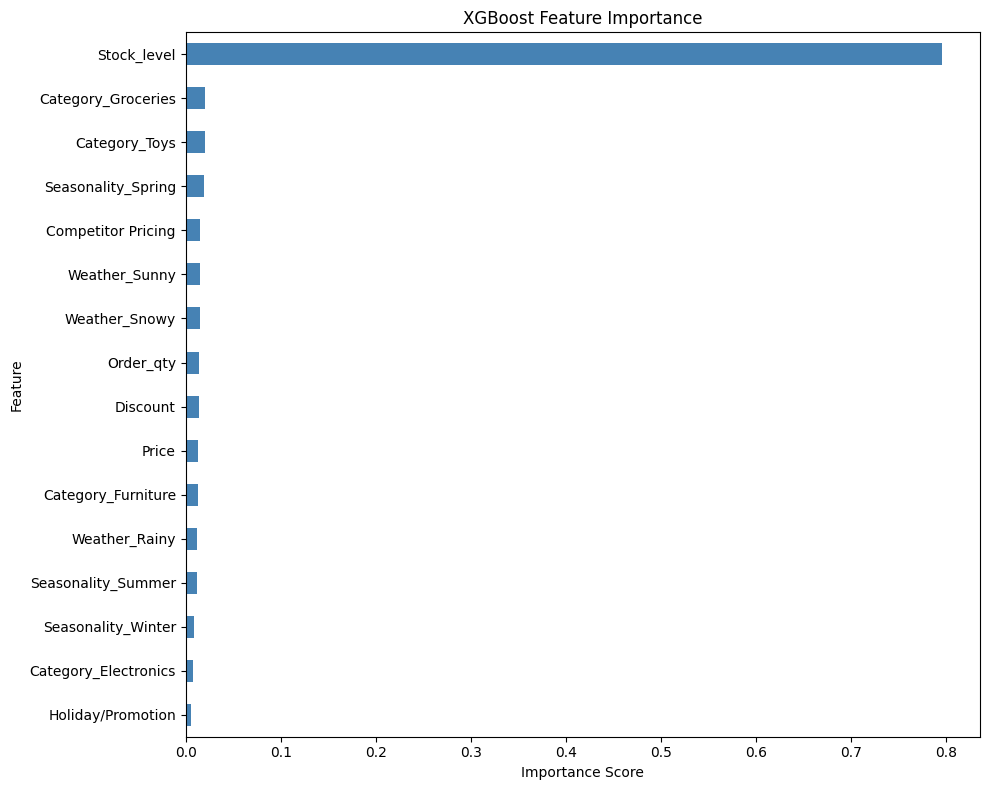


Top 5 Most Important Features:
Stock_level           0.795575
Category_Groceries    0.020637
Category_Toys         0.020368
Seasonality_Spring    0.019733
Competitor Pricing    0.015152
dtype: float32


In [59]:
# XGBoost Feature Importance
feat_importances = pd.Series(
    xgb.feature_importances_, 
    index=feature_cols_xgb)
feat_importances = feat_importances.sort_values()

plt.figure(figsize=(10, 8))
feat_importances.plot(kind='barh', color='steelblue')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feat_importances.sort_values(ascending=False).head())

The feature importance chart confirms Stock level as the most dominant predictor accounting for 79.6% of XGBoost predictive decisions.
The consistency across all three models confirms that in this dataset, Stock level is the primary driver for sales qty while the external factors (weather, seasonality, holiday/promotion) behave as noise.

With the above, below is the summary of R² of all four regression models.

Model 1: Linear Regression (Stock level only) - R²: 34.8%\
Model 2: Random Forest (Stock level only) - R²: 34.26%\
Model 3: Linear Regression (Stock level, Category & Order_qty) - R²: 34.8%\
Model 4: XGBoost default (16 features) - R²: 30.8% , XGBoost tuned (16 features) - R²: 34.6%

All models plateau around 34-35% Test R², confirming that the synthetic dataset's dominant signal (Stock Level, correlation 0.59) limits predictive performance regardless of model complexity. This also means the model captures only about 34-35% of the variation in sales quantity - the remaining 65% are unexplained by the features available or not well-presented in this dataset (i.e. real world factors like social trends, economic conditions)

Therefore, let's shift to a different analytical approach - Time Series Forecasting using ARIMA & SARIMA to address the forward-looking demand prediction aspect. 

#### Model 5 - Time Series Forecasting

#### Why Time Series Forecasting? 

The regression models (Model 1-4) answer: "What features predict Sales qty today?"
Time series forecasting answers a different question: "What will Sales qty look like next month?"

ARIMA and SARIMA use historical sales patterns - trends, seasonality and past values to forecast future demand. 
This addresses the unpredictable demand patterns and unforeseen surges, helping companies plan inventory proactively rather than reactively.

In [60]:
# Check if libraries are available
import statsmodels
import pmdarima
print("statsmodels version:", statsmodels.__version__)
print("pmdarima version:", pmdarima.__version__)

statsmodels version: 0.14.6
pmdarima version: 2.1.1


In [61]:
# Import required libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Group daily sales into monthly totals
monthly_sales = df.groupby(
    df['Date'].dt.to_period('M'))['Sales_qty'].sum()

# Convert period index to timestamp 
# (required for time series models)
monthly_sales.index = monthly_sales.index.to_timestamp()

# Quick check
print("Monthly Sales Data:")
print(monthly_sales)
print(f"\nTotal months available: {len(monthly_sales)}")

Monthly Sales Data:
Date
2022-01-01    419938
2022-02-01    391052
2022-03-01    426073
2022-04-01    407380
2022-05-01    414799
2022-06-01    415509
2022-07-01    426628
2022-08-01    424916
2022-09-01    411610
2022-10-01    426863
2022-11-01    414535
2022-12-01    412321
2023-01-01    423408
2023-02-01    385168
2023-03-01    416522
2023-04-01    401077
2023-05-01    418673
2023-06-01    405641
2023-07-01    437919
2023-08-01    416501
2023-09-01    405361
2023-10-01    425646
2023-11-01    416126
2023-12-01    418672
2024-01-01     13244
Freq: MS, Name: Sales_qty, dtype: int64

Total months available: 25


The data spans across Jan 2022 to Jan 2024 however Jan 2024 is not a full month of data as the data seems to be significantly lower than other months.
Including it would distort the forecasting model, hence let's remove Jan 2024 data to show 24 usable month

In [62]:
# Remove incomplete January 2024 data
monthly_sales = monthly_sales[monthly_sales.index < '2024-01-01']

# Confirm it's removed
print("Monthly Sales Data (cleaned):")
print(monthly_sales)
print(f"\nTotal months available: {len(monthly_sales)}")
print(f"Date range: {monthly_sales.index[0]} to {monthly_sales.index[-1]}")

Monthly Sales Data (cleaned):
Date
2022-01-01    419938
2022-02-01    391052
2022-03-01    426073
2022-04-01    407380
2022-05-01    414799
2022-06-01    415509
2022-07-01    426628
2022-08-01    424916
2022-09-01    411610
2022-10-01    426863
2022-11-01    414535
2022-12-01    412321
2023-01-01    423408
2023-02-01    385168
2023-03-01    416522
2023-04-01    401077
2023-05-01    418673
2023-06-01    405641
2023-07-01    437919
2023-08-01    416501
2023-09-01    405361
2023-10-01    425646
2023-11-01    416126
2023-12-01    418672
Freq: MS, Name: Sales_qty, dtype: int64

Total months available: 24
Date range: 2022-01-01 00:00:00 to 2023-12-01 00:00:00


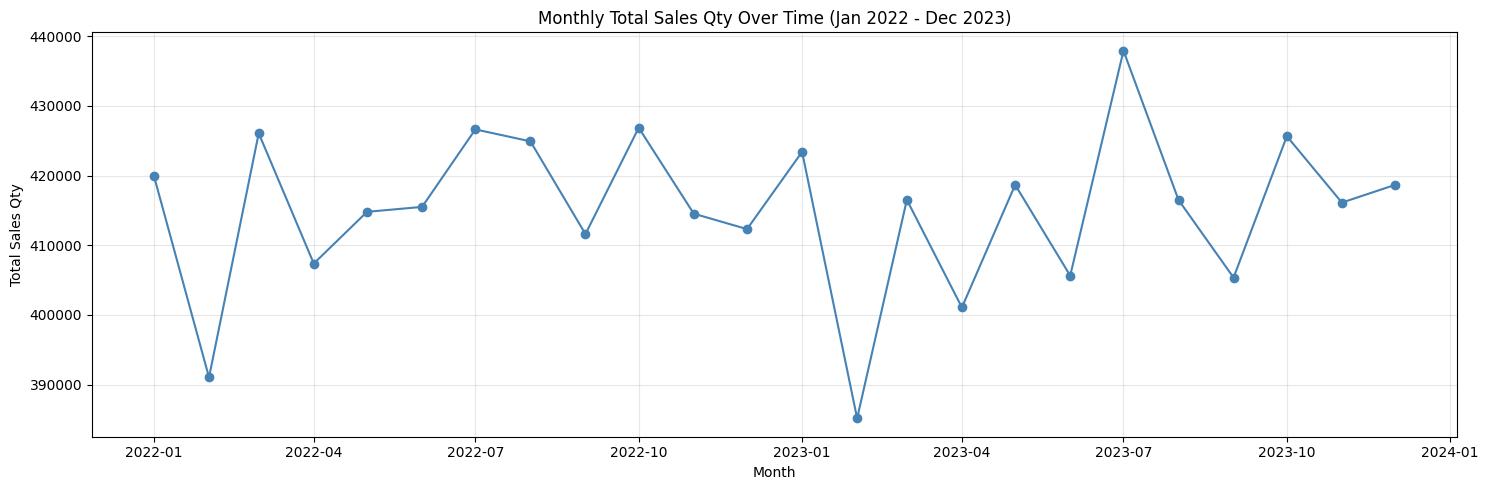

In [63]:
plt.figure(figsize=(15, 5))
plt.plot(monthly_sales, marker='o', color='steelblue')
plt.title('Monthly Total Sales Qty Over Time (Jan 2022 - Dec 2023)')
plt.xlabel('Month')
plt.ylabel('Total Sales Qty')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The monthly sales trend (Jan 2022 – Dec 2023) shows relatively stable fluctuations between approximately 385,000 and 437,000 units over the 24-month period, with no clear upward or downward trend. 

No strong seasonal pattern is visible — sales move irregularly month to month without a consistent repeating cycle. Two notable dips appear in February 2022 and February 2023, though these may be coincidental given the synthetic nature of the dataset.

This visual finding is consistent with our earlier EDA, which showed flat average sales across Weather conditions, Seasons and Holiday/Promotion days. 

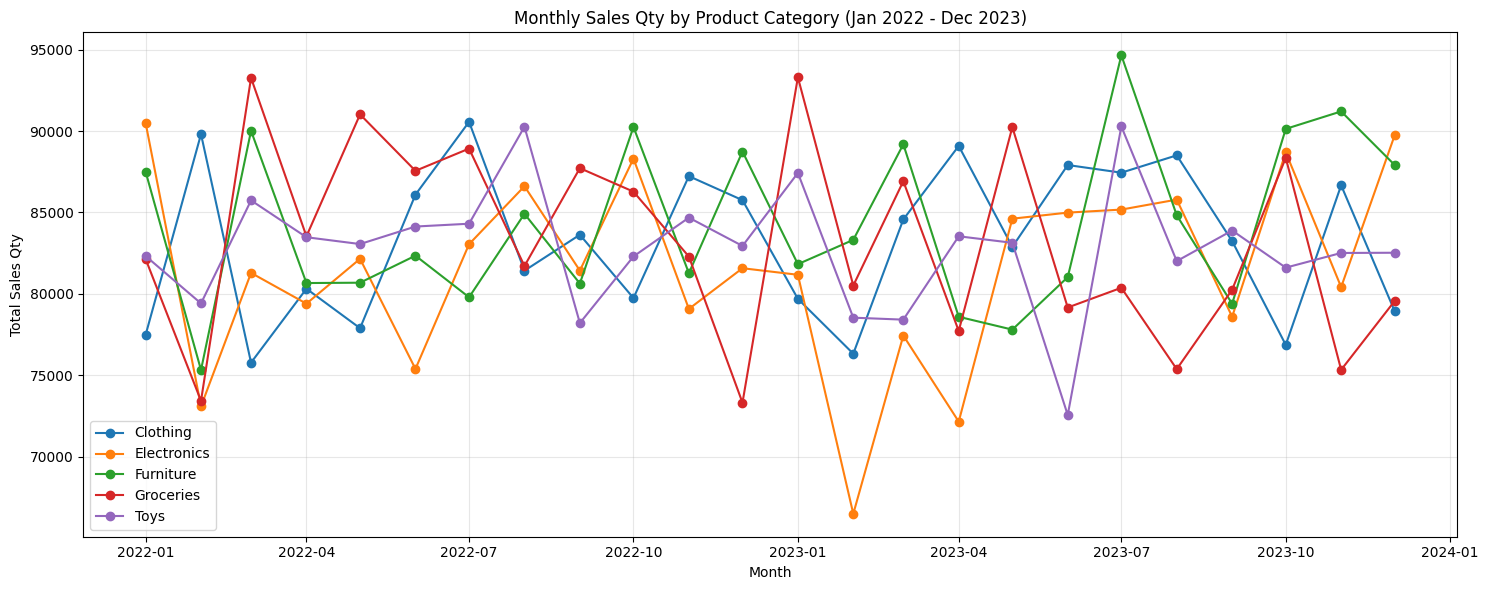


Monthly Sales by Category:
Category    Clothing  Electronics  Furniture  Groceries   Toys
Date                                                          
2022-01-01     77477        90499      87502      82139  82321
2022-02-01     89806        73086      75323      73426  79411
2022-03-01     75774        81286      90011      93263  85739
2022-04-01     80313        79395      80662      83534  83476
2022-05-01     77888        82150      80683      91021  83057
2022-06-01     86090        75387      82344      87555  84133
2022-07-01     90564        83049      79789      88920  84306
2022-08-01     81421        86608      84915      81708  90264
2022-09-01     83628        81427      80632      87719  78204
2022-10-01     79739        88306      90248      86275  82295
2022-11-01     87227        79072      81269      82288  84679
2022-12-01     85753        81573      88740      73314  82941
2023-01-01     79693        81170      81822      93298  87425
2023-02-01     76321       

In [64]:
# Group monthly sales by Category
monthly_sales_category = df.groupby(
    [df['Date'].dt.to_period('M'), 'Category'])['Sales_qty'].sum().unstack()

# Remove incomplete January 2024
monthly_sales_category = monthly_sales_category[
    monthly_sales_category.index < pd.Period('2024-01', freq='M')]

# Convert index to timestamp for plotting
monthly_sales_category.index = monthly_sales_category.index.to_timestamp()

# Plot monthly sales qty by product category
plt.figure(figsize=(15, 6))
for category in monthly_sales_category.columns:
    plt.plot(monthly_sales_category.index, 
             monthly_sales_category[category], 
             marker='o', label=category)

plt.title('Monthly Sales Qty by Product Category (Jan 2022 - Dec 2023)')
plt.xlabel('Month')
plt.ylabel('Total Sales Qty')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the actual numbers too
print("\nMonthly Sales by Category:")
print(monthly_sales_category.to_string())

In [65]:
# Summary: Total sales per category across full period
category_total = monthly_sales_category.sum().sort_values(ascending=False)
print("\nTotal Sales by Category (Jan 2022 - Dec 2023):")
print(category_total)
print(f"\nGrand Total: {category_total.sum():,}")


Total Sales by Category (Jan 2022 - Dec 2023):
Category
Furniture      2021964
Groceries      1998255
Clothing       1997776
Toys           1987245
Electronics    1957098
dtype: int64

Grand Total: 9,962,338


All five categories show irregular monthly fluctuations with no consistent seasonal pattern or trend.
One notable anomaly appears in Electronics (February 2023), which shows a sharp dip compared to other months and categories.

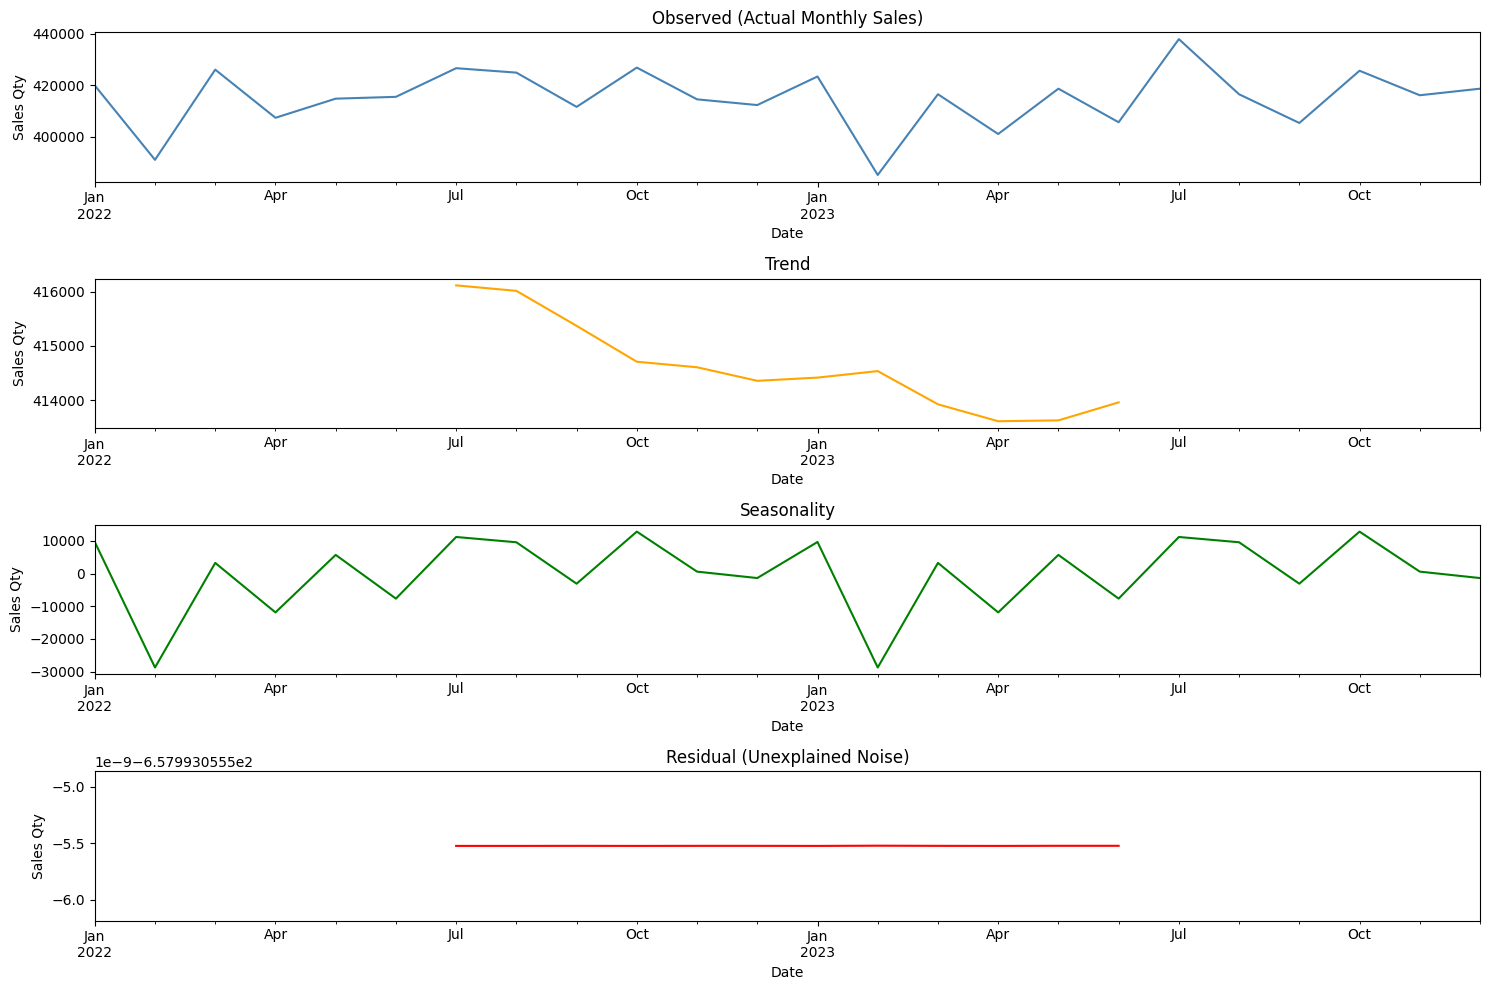

In [66]:
# Decompose the time series into its components (monthly sales trend (Jan 2022 – Dec 2023))
decomposition = seasonal_decompose(monthly_sales, 
                                    model='additive', 
                                    period=12)

fig, axes = plt.subplots(4, 1, figsize=(15, 10))

decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observed (Actual Monthly Sales)')
axes[0].set_ylabel('Sales Qty')

decomposition.trend.plot(ax=axes[1], color='orange')
axes[1].set_title('Trend')
axes[1].set_ylabel('Sales Qty')

decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_title('Seasonality')
axes[2].set_ylabel('Sales Qty')

decomposition.resid.plot(ax=axes[3], color='red')
axes[3].set_title('Residual (Unexplained Noise)')
axes[3].set_ylabel('Sales Qty')

plt.tight_layout()
plt.show()

These are the findings:\
Observed: This is the monthly sales trend from Jan 2022 – Dec 2023 between 385,000 and 437,000 units\
Trend: There is a slightly downward trend - sales declined roughly 1500 - 2000 units across the 24 month period\
Seasonality: There is a repeating seasonal pattern - driven by irregular spikes and dips (e.g. Feb dips)\
Residual: It shows a flat horizonal line, indicate that trend and seasonality together explain almost all variation in the data

### Let's check if the time series is stationary using the Augmented Dickey-Fuller (ADF) test.

In [67]:
# Augmented Dickey-Fuller (ADF) test
result = adfuller(monthly_sales)

print("=== Augmented Dickey-Fuller (ADF) Test ===")
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value:       {result[1]:.4f}")
print(f"Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

if result[1] <= 0.05:
    print("\n✅ Data IS stationary (p-value ≤ 0.05)")
    print("ARIMA can use this data directly")
else:
    print("\n⚠️ Data is NOT stationary (p-value > 0.05)")
    print("auto_arima will handle differencing automatically")

=== Augmented Dickey-Fuller (ADF) Test ===
ADF Statistic: -6.6708
p-value:       0.0000
Critical Values:
   1%: -3.7529
   5%: -2.9985
   10%: -2.6390

✅ Data IS stationary (p-value ≤ 0.05)
ARIMA can use this data directly


ADF test checks whether the monthly sales time series is stationary - a requirement for ARIMA modeling.\
The ADF stattistic is more negative than all three critical values and the P-value is below 0.05. This confirms the data is stationary and no differencing is required.\
ARIMA and SARIMA can use the monthly sales data directly without pre-processing. This is consistent with the decomposition analysis which showed an essentially flat trend across the 24-month period.

In [68]:
# Split into train and test
# Train: Jan 2022 – Sep 2023 (21 months)
# Test:  Oct 2023 – Dec 2023 (3 months)

train = monthly_sales[:'2023-09']
test = monthly_sales['2023-10':]

print("Training period:")
print(f"From: {train.index[0].strftime('%b %Y')}")
print(f"To:   {train.index[-1].strftime('%b %Y')}")
print(f"Months: {len(train)}")

print("\nTesting period:")
print(f"From: {test.index[0].strftime('%b %Y')}")
print(f"To:   {test.index[-1].strftime('%b %Y')}")
print(f"Months: {len(test)}")

Training period:
From: Jan 2022
To:   Sep 2023
Months: 21

Testing period:
From: Oct 2023
To:   Dec 2023
Months: 3


The monthly sales data is split into training and testing sets:

- **Training set**: January 2022 – September 2023 (21 months)
  → Used to train ARIMA and SARIMA models
- **Testing set**: October 2023 – December 2023 (3 months)
  → Used to evaluate forecast accuracy against actual sales

The last 3 months are held back as unseen test data to simulate a real-world scenario where the model forecasts future demand that hasn't happened yet.

### ARIMA Model

In [69]:
from pmdarima import auto_arima

# Run Auto ARIMA to find best parameters
# seasonal=False for plain ARIMA first
auto_model = auto_arima(train,        # learn from 21 months of training data
                         seasonal=False, # plain arima model, non-seasonal
                         stepwise=True, # tried combinations one step at a time and stops when the best one is found
                         suppress_warnings=True, # don't print warning messages while searching
                         error_action='ignore', # skip bad parameter combination, w/o this, Auto Arima would crash when it hits a bad combination
                         information_criterion='aic') # pick the model with the best AIC score. AIC stands for Alkaike Information Criterion

print("=== Auto ARIMA Results ===")
print(f"Best ARIMA order found: p={auto_model.order[0]}, d={auto_model.order[1]}, q={auto_model.order[2]}")
print(f"\nModel Summary:")
print(auto_model.summary())

=== Auto ARIMA Results ===
Best ARIMA order found: p=1, d=0, q=0

Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   21
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -225.798
Date:                Sun, 26 Jul 2026   AIC                            457.595
Time:                        11:14:02   BIC                            460.729
Sample:                    01-01-2022   HQIC                           458.275
                         - 09-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   5.609e+05   1.13e+05      4.966      0.000     3.4e+05    7.82e+05
ar.L1         -0.3535      0.270     -1.308      0

The model output displays SARIMA results - this is the underlying statsmodels engine used for all ARIMA variants. With seasonal = false , this is equivalent to a plain ARIMA model.
Based on all combinations checked, ARIMA (1,0,0) p=1, d=0 and q=0 is the most optimal (i.e. lowest possible AIC score; estimator of out-of-sample prediction error).

In [70]:
from statsmodels.tsa.arima.model import ARIMA

# Build ARIMA model using Auto ARIMA's recommended parameters
arima_model = ARIMA(train, order=(1, 0, 0))
arima_fit = arima_model.fit()

# Forecast 3 months ahead (Oct, Nov, Dec 2023)
arima_forecast = arima_fit.forecast(steps=3)
arima_forecast.index = test.index

print("=== ARIMA(1,0,0) Forecast vs Actual ===")
print(f"\n{'Month':<15} {'Forecast':>12} {'Actual':>12} {'Units Off':>12} {'% Off':>10}")
print("-" * 65)

for date, forecast_val, actual_val in zip(test.index, arima_forecast, test):
    units_off = actual_val - forecast_val
    pct_off = abs(units_off) / actual_val * 100
    print(f"{date.strftime('%b %Y'):<15} {forecast_val:>12,.0f} {actual_val:>12,.0f} {units_off:>12,.0f} {pct_off:>9.1f}%")

=== ARIMA(1,0,0) Forecast vs Actual ===

Month               Forecast       Actual    Units Off      % Off
-----------------------------------------------------------------
Oct 2023             417,447      425,646        8,199       1.9%
Nov 2023             413,330      416,126        2,796       0.7%
Dec 2023             414,732      418,672        3,940       0.9%


In [71]:
# Calculate ARIMA accuracy metrics
mae = mean_absolute_error(test, arima_forecast)
rmse = np.sqrt(mean_squared_error(test, arima_forecast))
mape = np.mean(np.abs((test - arima_forecast) / test)) * 100

print("=== ARIMA(1,0,0) Accuracy Metrics ===")
print(f"MAE  (Mean Absolute Error):        {mae:,.0f} units")
print(f"RMSE (Root Mean Squared Error):    {rmse:,.0f} units")
print(f"MAPE (Mean Absolute % Error):      {mape:.1f}%")

=== ARIMA(1,0,0) Accuracy Metrics ===
MAE  (Mean Absolute Error):        4,978 units
RMSE (Root Mean Squared Error):    5,494 units
MAPE (Mean Absolute % Error):      1.2%


The metrics show the average monthly forecast error was 4,978 units (MAE), with RMSE slightly higher at 5,494 units — indicating no extreme outlier errors across the 3 forecast months (Oct-Dec 2023). A MAPE of 1.2% is well below the industry benchmark of 10%, confirming the ARIMA (1,0,0) model achieved highly accurate forecasts.

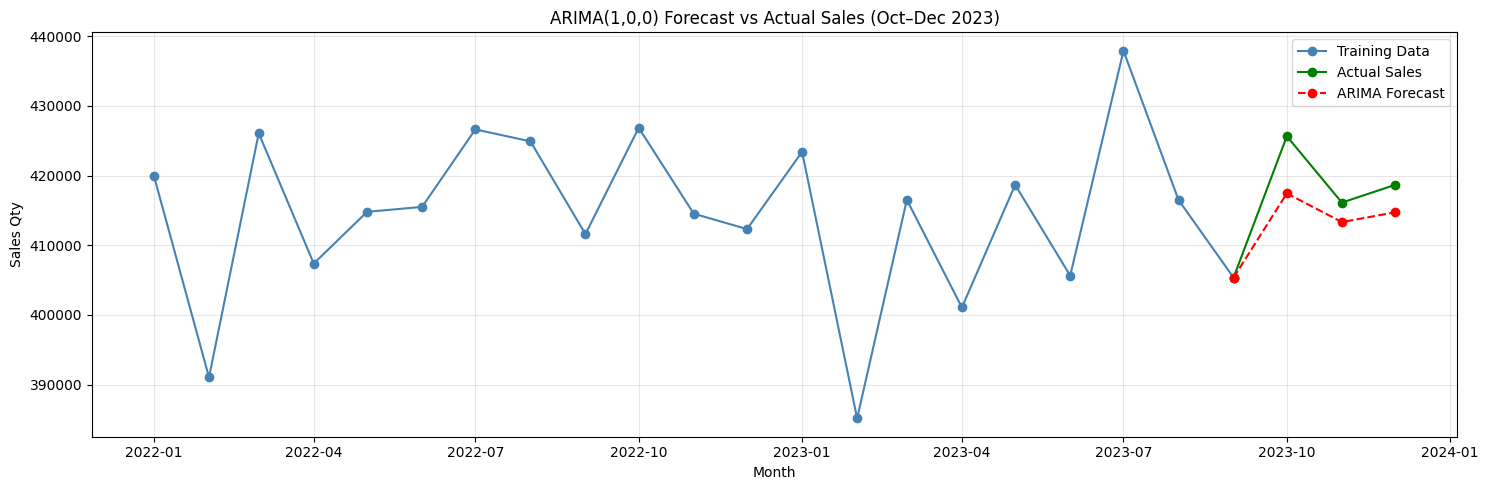

In [72]:
plt.figure(figsize=(15, 5))

# Plot training data
plt.plot(train, marker='o', color='steelblue', label='Training Data')

# Add last training point to connect the lines
bridge = pd.Series([train.iloc[-1]], index=[train.index[-1]])

# Plot actual and forecast starting from last training point
plt.plot(pd.concat([bridge, test]), marker='o', color='green', label='Actual Sales')
plt.plot(pd.concat([bridge, arima_forecast]), marker='o', color='red', linestyle='--', label='ARIMA Forecast')

plt.title('ARIMA(1,0,0) Forecast vs Actual Sales (Oct–Dec 2023)')
plt.xlabel('Month')
plt.ylabel('Sales Qty')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### SARIMA Model

In [73]:
# Run Auto ARIMA with seasonal=True to find SARIMA parameters
auto_sarima = auto_arima(train,
                          seasonal=True,      # Running Auto Sarima(p,d,q) with seasonal factor 
                          m=12,               # telling Sarima model there is a seasonal cycle that repeats 12 months
                          stepwise=True,
                          suppress_warnings=True,
                          error_action='ignore',
                          information_criterion='aic')

print("=== Auto SARIMA Results ===")
print(f"Best SARIMA order: {auto_sarima.order}")
print(f"Best Seasonal order: {auto_sarima.seasonal_order}")
print(auto_sarima.summary())

=== Auto SARIMA Results ===
Best SARIMA order: (0, 0, 2)
Best Seasonal order: (0, 1, 0, 12)
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                   21
Model:             SARIMAX(0, 0, 2)x(0, 1, [], 12)   Log Likelihood                   0.000
Date:                             Sun, 26 Jul 2026   AIC                              8.000
Time:                                     11:14:08   BIC                              8.789
Sample:                                 01-01-2022   HQIC                             6.298
                                      - 09-01-2023                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   15

The output indicates that the best SARIMA model is p=0, d=0 & q=2 (0,0,2) with seasonal order (0, 1, 0, 12). 

However, the model did not fit properly - all diagnostic tests returned NaN values and Log Likelihood was 0, indicating a degenerate model. This occurred because D was not specified in SARIMA model and letting it search for the best D (D=1).
With seasonal differencing (D=1) and m=12 consumed 12 of the 21 available training months, leaving insufficient data for reliable model fitting. 

Next, we re-run Auto SARIMA with D=0 (no seasonal differencing) to resolve this below.

In [74]:
# Force D=0 to avoid over-differencing
auto_sarima = auto_arima(train,
                          seasonal=True,
                          m=12,
                          D=0,          # force no seasonal differencing
                          stepwise=True,
                          suppress_warnings=True,
                          error_action='ignore',
                          information_criterion='aic')

print("=== Auto SARIMA Results (D=0) ===")
print(f"Best SARIMA order: {auto_sarima.order}")
print(f"Best Seasonal order: {auto_sarima.seasonal_order}")
print(auto_sarima.summary())

=== Auto SARIMA Results (D=0) ===
Best SARIMA order: (1, 0, 0)
Best Seasonal order: (0, 0, 1, 12)
                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                   21
Model:             SARIMAX(1, 0, 0)x(0, 0, [1], 12)   Log Likelihood                -223.874
Date:                              Sun, 26 Jul 2026   AIC                            455.747
Time:                                      11:14:17   BIC                            459.925
Sample:                                  01-01-2022   HQIC                           456.654
                                       - 09-01-2023                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------


Re-runing Auto Sarima with D=0 (no seasonal differencing) produced a valid model: SARIMA(1,0,0)(0,0,1,12).

Key parameters found: 

p=1, d=0, q=0 -same as ARIMA, using last month's sales as the primary predictor\
Q=1, m=12 - adds a seasonal moving average component, using the forecast error from the same month last year as an additional signal

AIC comparison:

SARIMA (455.747) vs ARIMA (457.595) \
SARIMA achieved a lower AIC on training data suggesting marginally better fit


In [75]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Build SARIMA model using Auto SARIMA's recommended parameters
sarima_model = SARIMAX(train,
                        order=auto_sarima.order,
                        seasonal_order=auto_sarima.seasonal_order)
sarima_fit = sarima_model.fit(disp=False)

# Forecast 3 months ahead (Oct, Nov, Dec 2023)
sarima_forecast = sarima_fit.forecast(steps=3)
sarima_forecast.index = test.index

print("=== SARIMA(1,0,0)(0,0,1,12) Forecast vs Actual ===")
print(f"\n{'Month':<15} {'Forecast':>12} {'Actual':>12} {'Units Off':>12} {'% Off':>10}")
print("-" * 65)

for date, forecast_val, actual_val in zip(test.index, sarima_forecast, test):
    units_off = actual_val - forecast_val
    pct_off = abs(units_off) / actual_val * 100
    print(f"{date.strftime('%b %Y'):<15} {forecast_val:>12,.0f} {actual_val:>12,.0f} {units_off:>12,.0f} {pct_off:>9.1f}%")

=== SARIMA(1,0,0)(0,0,1,12) Forecast vs Actual ===

Month               Forecast       Actual    Units Off      % Off
-----------------------------------------------------------------
Oct 2023             410,583      425,646       15,063       3.5%
Nov 2023             404,869      416,126       11,257       2.7%
Dec 2023             403,168      418,672       15,504       3.7%


In [76]:
# SARIMA accuracy metrics
mae_sarima = mean_absolute_error(test, sarima_forecast)
rmse_sarima = np.sqrt(mean_squared_error(test, sarima_forecast))
mape_sarima = np.mean(np.abs((test - sarima_forecast) / test)) * 100

print("=== SARIMA(1,0,0)(0,0,1,12) Accuracy Metrics ===")
print(f"MAE  (Mean Absolute Error):        {mae_sarima:,.0f} units")
print(f"RMSE (Root Mean Squared Error):    {rmse_sarima:,.0f} units")
print(f"MAPE (Mean Absolute % Error):      {mape_sarima:.1f}%")

=== SARIMA(1,0,0)(0,0,1,12) Accuracy Metrics ===
MAE  (Mean Absolute Error):        13,941 units
RMSE (Root Mean Squared Error):    14,071 units
MAPE (Mean Absolute % Error):      3.3%


Despite achieving a lower AIC on training data (455.747 vs 457.595), SARIMA performed worse than ARIMA on all metrics.

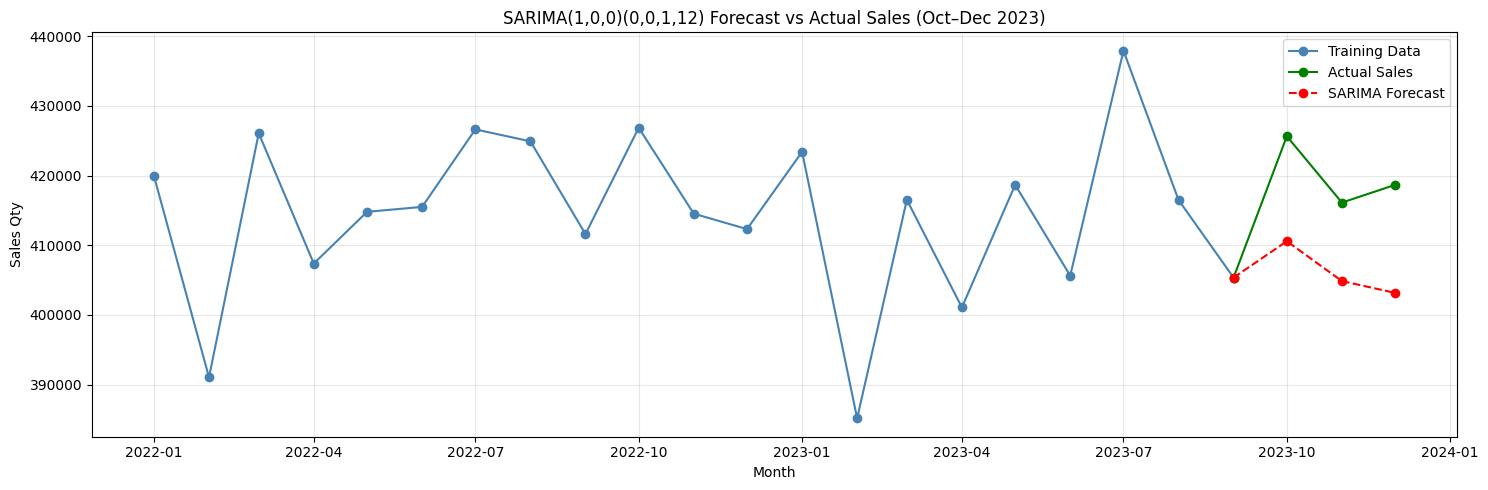

In [77]:
plt.figure(figsize=(15, 5))

# Plot training data
plt.plot(train, marker='o', color='steelblue', label='Training Data')

# Bridge point
bridge = pd.Series([train.iloc[-1]], index=[train.index[-1]])

# Plot actual and SARIMA forecast
plt.plot(pd.concat([bridge, test]), marker='o', color='green', label='Actual Sales')
plt.plot(pd.concat([bridge, sarima_forecast]), marker='o', color='red', 
         linestyle='--', label='SARIMA Forecast')

plt.title('SARIMA(1,0,0)(0,0,1,12) Forecast vs Actual Sales (Oct–Dec 2023)')
plt.xlabel('Month')
plt.ylabel('Sales Qty')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

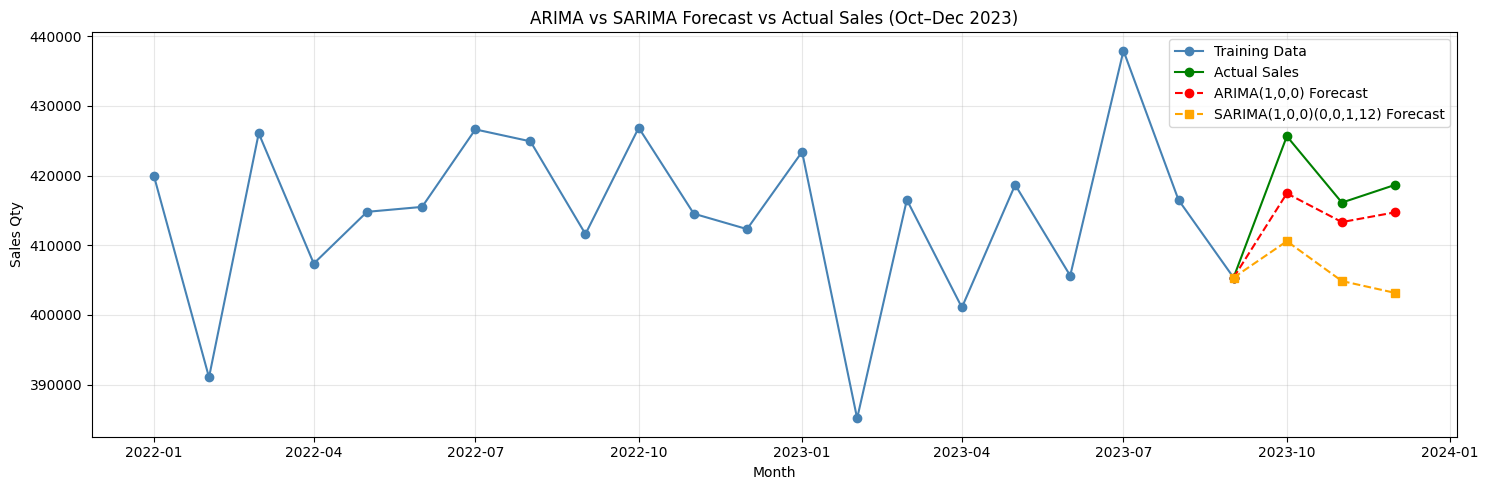

In [78]:
plt.figure(figsize=(15, 5))

# Training data
plt.plot(train, marker='o', color='steelblue', label='Training Data')

# Bridge point
bridge = pd.Series([train.iloc[-1]], index=[train.index[-1]])

# Actual sales
plt.plot(pd.concat([bridge, test]), marker='o', 
         color='green', label='Actual Sales')

# ARIMA forecast
plt.plot(pd.concat([bridge, arima_forecast]), marker='o', 
         color='red', linestyle='--', label='ARIMA(1,0,0) Forecast')

# SARIMA forecast
plt.plot(pd.concat([bridge, sarima_forecast]), marker='s', 
         color='orange', linestyle='--', label='SARIMA(1,0,0)(0,0,1,12) Forecast')

plt.title('ARIMA vs SARIMA Forecast vs Actual Sales (Oct–Dec 2023)')
plt.xlabel('Month')
plt.ylabel('Sales Qty')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### ARIMA vs SARIMA Combined Forecast Comparison

The combined chart clearly shows ARIMA(1,0,0) outperforming SARIMA(1,0,0)(0,0,1,12) across all three forecast months:

- ARIMA (red) tracks actual sales (green) closely throughout October to December 2023
- SARIMA (orange) consistently underforecasts and drifts further from actual sales over time — widening from 15,063 units off in October to 15,504 units off in December

**Full Model Comparison:**

| Metric | ARIMA(1,0,0) | SARIMA(1,0,0)(0,0,1,12) |
|--------|--------------|--------------------------|
| Oct Units Off | 8,199 | 15,063 |
| Nov Units Off | 2,796 | 11,257 |
| Dec Units Off | 3,940 | 15,504 |
| MAE | 4,978 units | 13,941 units |
| RMSE | 5,494 units | 14,071 units |
| MAPE | **1.2%** | 3.3% |

**Conclusion:** 

ARIMA(1,0,0) is the preferred forecasting model for this dataset. With only 21 training months, SARIMA did not have enough data to learn reliable seasonal patterns.

### Summary of all Models

**Regression Models — "What drives sales quantity?"**

| Model | Features | Train R² | Test R² |
|-------|----------|----------|---------|
| Linear Regression | Stock Level | 0.348 | 0.348 |
| Random Forest | Stock Level | 0.354 | 0.343 |
| Linear Regression | Stock Level + Category + Order Qty | 0.348 | 0.348 |
| XGBoost | All 16 features | 0.507 | 0.308 |
| XGBoost (tuned) | All 16 features | 0.356 | 0.346 |

**Time Series Models — "What will demand be next month?"**

| Model | MAE | RMSE | MAPE |
|-------|-----|------|------|
| ARIMA(1,0,0) | 4,978 units | 5,494 units | **1.2%** |
| SARIMA(1,0,0)(0,0,1,12) | 13,941 units | 14,071 units | 3.3% |


### Key Findings

1. **Stock Level is the dominant driver of sales** - validated three ways: correlation (0.59), flat EDA averages for all other features, and XGBoost feature importance (79.6%).

2. **All regression models plateaued at ~34-35% Test R²** - the synthetic dataset carries weak signal beyond Stock Level, limiting predictive power regardless of model complexity.

3. **ARIMA(1,0,0) is the best forecasting model** - 1.2% MAPE on 3-month forecasts. SARIMA performed worse (3.3%) due to insufficient seasonal history (< 2 full annual cycles).

4. **Simpler models won consistently** - in both regression and time series, added complexity did not improve results on this dataset.